In [16]:
%pip install networkx matplotlib pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
%load_ext autoreload
%autoreload 2

import cpg_trie_parser as cpg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from pathlib import Path
import pydot
import networkx as nx

dot_path = Path("services/frontend/export.dot")

dot_text = dot_path.read_text(encoding="utf-8")
graphs = pydot.graph_from_dot_data(dot_text)

P = graphs[0]
P

In [19]:
G = nx.MultiDiGraph()

for node in P.get_nodes():
    name = node.get_name()
    if name in (None, "node", "graph", "edge"):
        continue
    nid = str(name).strip('"')
    attrs = {k: v for k, v in node.get_attributes().items()}
    G.add_node(nid, **attrs)

for edge in P.get_edges():
    src = str(edge.get_source()).strip('"')
    dst = str(edge.get_destination()).strip('"')
    attrs = {k: v for k, v in edge.get_attributes().items()}
    G.add_edge(src, dst, **attrs)

print(G.number_of_nodes(), G.number_of_edges())

30548 164385


In [ ]:
from typing import List, Tuple
import csv

def extract_logs(dataset_path: str, service: str, start_time: int, end_time: int) -> List[Tuple[str, str]]:
    logs = []
    try:
        with open(dataset_path, 'r') as f:
            reader = csv.reader(f)
            next(reader, None)
            for row in reader:
                if len(row) < 3:
                    continue
                try:
                    timestamp   = int(float(row[0]))
                    log_service = row[1].strip()
                    message     = row[2].strip()
                    if log_service.lower() == service.lower() and start_time <= timestamp <= end_time:
                        bucket = f"{log_service}@{timestamp}"
                        logs.append((bucket, message))
                except (ValueError, IndexError):
                    continue
    except FileNotFoundError:
        print(f"ERROR: Dataset file not found: {dataset_path}")
    print(f"✓ Extracted {len(logs)} logs for {service} in time window")
    return logs

In [ ]:
dataset = "./dataset/re3ob_adservice_f3_1/logs.csv"
service = "frontend"
start = 1731903974
end = 1731903980
logs = extract_logs(dataset, service, start, end)

✓ Extracted 107 logs for frontend in time window


In [ ]:
templates = cpg.build_templates_from_cpg(G, max_ddg_depth=5)
root = cpg.build_trie(templates)
cpg.visualize_trie_matplotlib(root, output_path="trie.png")

[Trie] Saved matplotlib PNG -> trie.png


In [ ]:
print("Templates:", len(templates))
for t in templates[:10]:
    print(f"[{t.call_node_id}] {t.method_name}() -> {t.raw_template} (static={t.static_count})")

Templates: 77
[30064771307] loadDeploymentDetails() -> failed to fetch the hostname for the pod <*> (static=8)
[30064771312] loadDeploymentDetails() -> failed to fetch the name of the cluster in which the pod is running <*> (static=14)
[30064771317] loadDeploymentDetails() -> failed to fetch the zone of the node where the pod is scheduled <*> (static=13)
[30064771328] loadDeploymentDetails() -> loaded deployment details <*> (static=3)
[30064772872] AddItem() -> method additem not implemented <*> (static=4)
[30064772874] GetCart() -> method getcart not implemented <*> (static=4)
[30064772876] EmptyCart() -> method emptycart not implemented <*> (static=4)
[30064772938] ListRecommendations() -> method listrecommendations not implemented <*> (static=4)
[30064772994] ListProducts() -> method listproducts not implemented <*> (static=4)
[30064772996] GetProduct() -> method getproduct not implemented <*> (static=4)


In [ ]:
mappings = cpg.map_logs(logs, root, templates, min_static=1)
print(f"Mappings: {len(mappings)}\n")

rows = []
for m in mappings:
    rows.append({
        "bucket":          m.bucket,
        "matched":         "✓" if m.matched else "✗",
        "method_name":     m.method_name if m.method_name else "—",
        "template":        m.template    if m.template    else "—",
        "score":           m.score,
        "call_node_id":    m.call_node_id    if m.call_node_id    else "—",
        "method_node_id":  m.method_node_id  if m.method_node_id  else "—",
        "message":         m.message,
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 200)
df

Mappings: 107



,bucket,matched,method_name,template,score,call_node_id,method_node_id,message
0,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
1,frontend@1731903974,✓,productHandler,serving product page <*>,3,30064773422,107374182767,serving product page
2,frontend@1731903974,✗,—,—,0,—,—,request complete
3,frontend@1731903974,✗,—,—,0,—,—,request complete
4,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
5,frontend@1731903974,✓,addToCartHandler,adding to cart <*>,3,30064773495,107374182768,adding to cart
6,frontend@1731903974,✗,—,—,0,—,—,request complete
7,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
8,frontend@1731903974,✓,viewCartHandler,view user cart <*>,3,30064773548,107374182770,view user cart
9,frontend@1731903974,✗,—,—,0,—,—,request complete


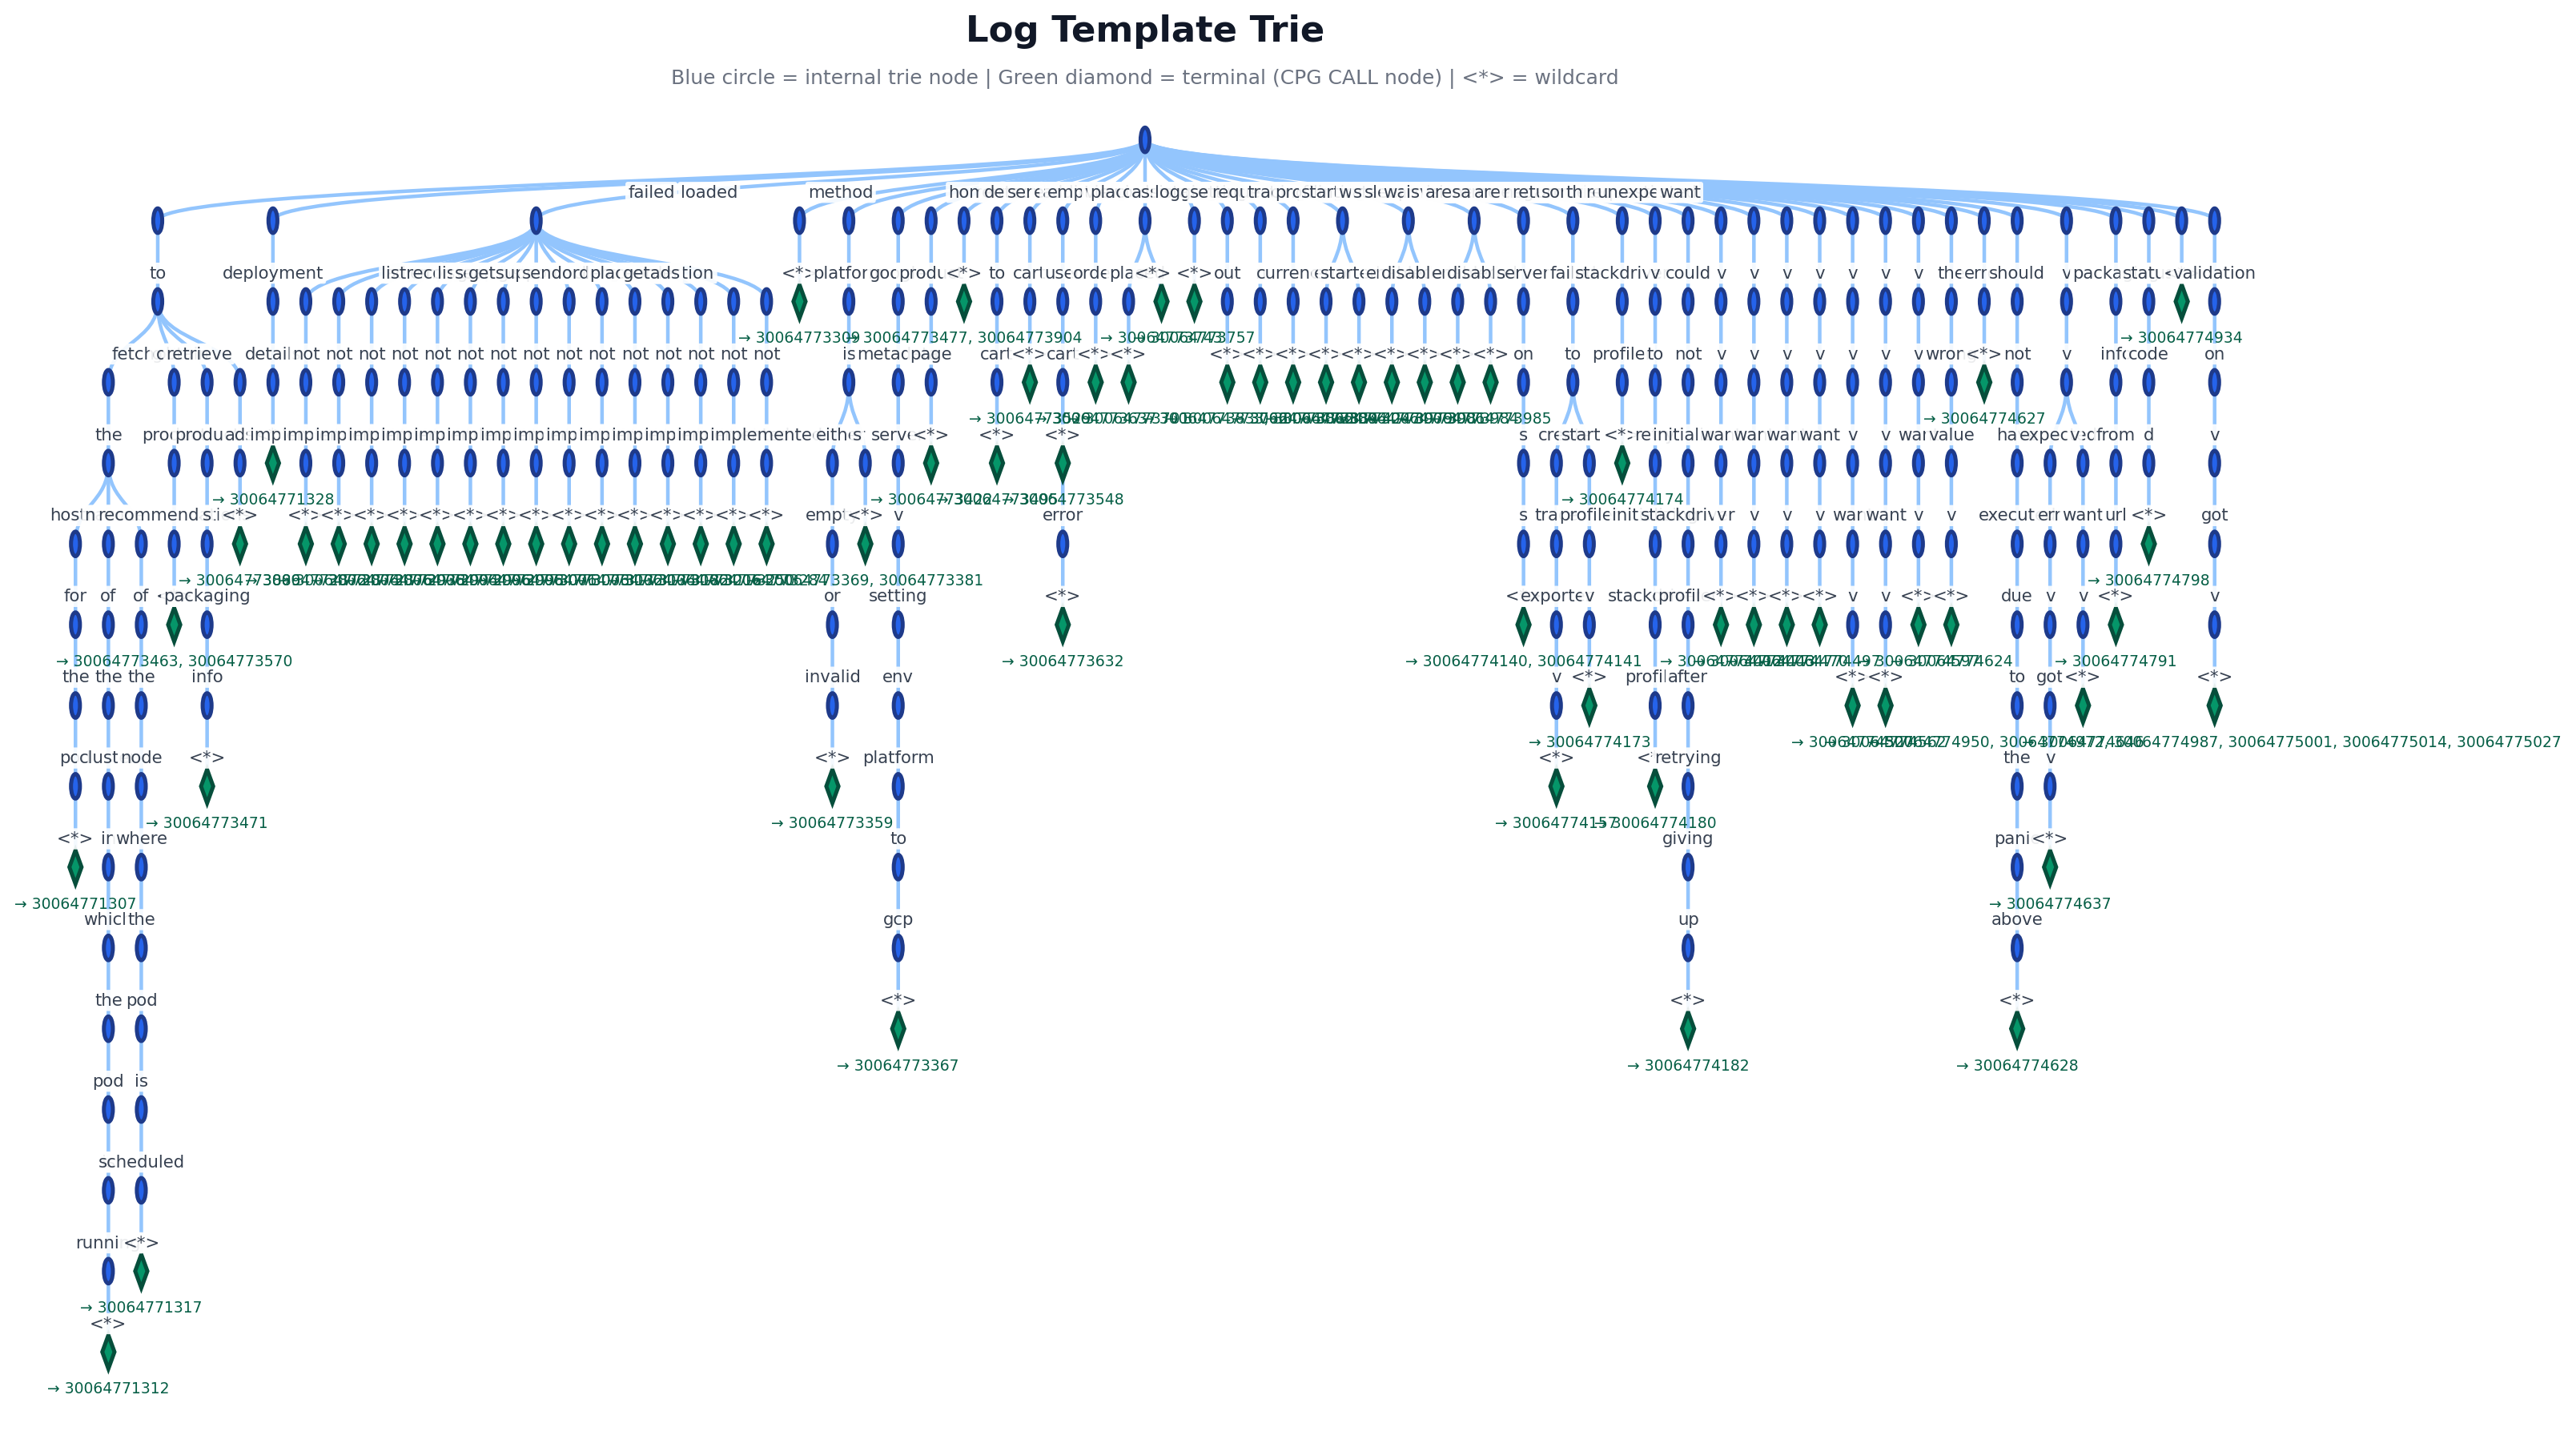

In [ ]:
from IPython.display import Image, display
display(Image(filename="trie.png"))

In [40]:
import html
from typing import Dict, List

import html
from typing import Dict, List

def _attr(nid: str, key: str) -> str:
    """Достаёт атрибут узла, убирает обёрточные кавычки и HTML-entities."""
    raw = G.nodes.get(nid, {}).get(key, "")
    s = html.unescape(str(raw)).strip()
    # Убираем обёрточные кавычки: '"METHOD"' -> 'METHOD'
    if s.startswith('"') and s.endswith('"'):
        s = s[1:-1]
    elif s.startswith("'") and s.endswith("'"):
        s = s[1:-1]
    return s

def _label(nid: str) -> str:
    return _attr(nid, "label").upper()

_PROJECT_PREFIXES = (
    "main.",
    "main<",
    "github.com/GoogleCloudPlatform/microservices-demo/src/frontend",
)

def _is_internal_method(nid: str) -> bool:
    if _label(nid) != "METHOD":
        return False
    fn = _attr(nid, "FULL_NAME")
    if not fn or fn.startswith("<"):
        return False
    # IS_EXTERNAL с подчёркиванием, значение тоже в кавычках -> уже очищено _attr
    is_ext = _attr(nid, "IS_EXTERNAL").lower()
    if is_ext == "true":
        return False
    return fn.startswith(_PROJECT_PREFIXES)

def get_method_call_info(method_node_id: str) -> Dict:
    info = {
        "node_id":   method_node_id,
        "name":      _attr(method_node_id, "NAME"),
        "full_name": _attr(method_node_id, "FULL_NAME"),
        "filename":  _attr(method_node_id, "FILENAME"),
        "callees":   [],
        "callers":   [],
    }
    method_by_fullname: Dict[str, str] = {
        _attr(nid, "FULL_NAME"): nid
        for nid in G.nodes()
        if _is_internal_method(nid)
    }

    # --- CALLEES ---
    seen_callees: set = set()
    for _, v, d in G.out_edges(method_node_id, data=True):
        el = html.unescape(str(d.get("label", ""))).strip().strip('"').upper()
        if el != "CONTAINS" or _label(v) != "CALL":
            continue
        mfn = _attr(v, "METHOD_FULL_NAME")
        if mfn in method_by_fullname and mfn not in seen_callees:
            seen_callees.add(mfn)
            callee_nid = method_by_fullname[mfn]
            info["callees"].append({
                "name":           _attr(callee_nid, "NAME"),
                "full_name":      mfn,
                "method_node_id": callee_nid,
                "call_code":      _attr(v, "CODE"),
            })

    # --- CALLERS: ищем по METHOD_FULL_NAME и по NAME ---
    my_full_name = info["full_name"]
    my_name      = info["name"]
    seen_callers: set = set()

    for caller_call_nid in G.nodes():
        if _label(caller_call_nid) != "CALL":
            continue
        mfn  = _attr(caller_call_nid, "METHOD_FULL_NAME")
        name = _attr(caller_call_nid, "NAME")
        # Совпадение по FULL_NAME ИЛИ по NAME (для случаев когда FULL_NAME не заполнен)
        if mfn != my_full_name and name != my_name:
            continue
        for pu, _, pd in G.in_edges(caller_call_nid, data=True):
            pel = html.unescape(str(pd.get("label", ""))).strip().strip('"').upper()
            if pel == "CONTAINS" and _is_internal_method(pu) and pu not in seen_callers:
                seen_callers.add(pu)
                info["callers"].append({
                    "name":           _attr(pu, "NAME"),
                    "full_name":      _attr(pu, "FULL_NAME"),
                    "method_node_id": pu,
                    "call_code":      _attr(caller_call_nid, "CODE"),
                })
    return info

In [45]:
import pandas as pd

def display_method_info(method_node_id: str):
    info = get_method_call_info(method_node_id)
    print(f"📦 {info['name']}  (node: {info['node_id']})")
    print(f"   {info['full_name']}")

    print(f"\n⬇️  Вызывает ({len(info['callees'])}):")
    if info["callees"]:
        display(pd.DataFrame(info["callees"]))
    else:
        print("  (нет внутренних вызовов)")

    print(f"\n⬆️  Вызывается из ({len(info['callers'])}):")
    if info["callers"]:
        display(pd.DataFrame(info["callers"]))
    else:
        print("  (никто не вызывает)")

# Пример:
display_method_info("107374182777")  # chooseAd

📦 chooseAd  (node: 107374182777)
   main.frontendServer.chooseAd

⬇️  Вызывает (1):


,name,full_name,method_node_id,call_code
0,getAd,main.frontendServer.getAd,107374182851,"fe.getAd(ctx, ctxKeys)"



⬆️  Вызывается из (0):
  (никто не вызывает)
